# Laboratorio 4: Análisis de Datos GeoEspaciales

CC3084 – Data Science

Iris Ayala - Anggie Quezada - Jonathan Diaz

Análisis de la proliferación de cianobacteria en los lagos de Atitlán y Amatitlán usando imágenes Sentinel-2.

## Librerías

In [21]:
import os
import time
import openeo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta
from dotenv import load_dotenv
from sentinelhub import SHConfig, SentinelHubRequest, SentinelHubSession, DataCollection, MimeType, CRS, BBox, bbox_to_dimensions

## 1. Conexión con la API de Sentinel-2

In [22]:
connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
).authenticate_oidc()

Authenticated using refresh token.


In [23]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## 2. Obtención de los datos raster

### Coordenadas de los lagos

In [24]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

### Fechas oficiales por lago

In [25]:
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28", "2026-06-19"
]

### Configuración de Sentinel Hub

In [26]:
load_dotenv()

config = SHConfig()
config.sh_client_id = os.environ["SH_CLIENT_ID"]
config.sh_client_secret = os.environ["SH_CLIENT_SECRET"]
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

coleccion_s2 = DataCollection.SENTINEL2_L2A.define_from("coleccion_s2", service_url=config.sh_base_url)

### Descarga de bandas

Se descargan únicamente las bandas B03, B04 y B08, necesarias para calcular NDVI y NDWI.

In [27]:
evalscript_bandas = """
//VERSION=3
function setup() {
  return {
    input: ["B03", "B04", "B08"],
    output: { bands: 3, sampleType: "UINT16" }
  };
}
function evaluatePixel(s) {
  return [s.B03, s.B04, s.B08];
}
"""

In [28]:
def descargar_bandas(bbox_dict, fecha, intentos=3):
    bbox = BBox(bbox=[bbox_dict["west"], bbox_dict["south"], bbox_dict["east"], bbox_dict["north"]], crs=CRS.WGS84)
    tamano = bbox_to_dimensions(bbox, resolution=20)
    solicitud = SentinelHubRequest(
        evalscript=evalscript_bandas,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=coleccion_s2,
                time_interval=(fecha, fecha)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=tamano,
        config=config
    )
    for intento in range(intentos):
        try:
            return solicitud.get_data()[0]
        except Exception:
            if intento == intentos - 1:
                raise
            SentinelHubSession.clear_cache()
            time.sleep(5)

In [29]:
bandas_atitlan = {fecha: descargar_bandas(lago_atitlan, fecha) for fecha in fechas_atitlan}
bandas_amatitlan = {fecha: descargar_bandas(lago_amatitlan, fecha) for fecha in fechas_amatitlan}

### Verificación de una imagen descargada

In [30]:
print("Dimensiones:", bandas_atitlan[fechas_atitlan[0]].shape)

Dimensiones: (875, 1365, 3)


**Interpretación**

Las dimensiones obtenidas corresponden al recorte del área de cada lago a una resolución de 20 metros por pixel, con 3 bandas (B03, B04, B08). El tamaño coincide con lo esperado para el tamaño geográfico de cada lago.

## 3. Índice de cianobacteria, NDVI y NDWI

### 3.1 Script de detección de cianobacteria

Se usa el script "Cyanobacteria Chlorophyll-a NDCI L1C" de https://custom-scripts.sentinel-hub.com. El script original devuelve un color RGB para visualizar la floración. Se adapta la salida para que devuelva el valor numérico de clorofila-a (`chl`) en lugar del color, manteniendo la misma lógica de detección de agua y el mismo modelo NDCI, ya que el análisis temporal y de correlación (Ejercicio 4) necesita valores numéricos.

Valores de salida:
- `0`: pixel que no es agua.
- `-1`: agua con floración superficial detectada (índice de vegetación flotante alto).
- cualquier otro valor: estimado de clorofila-a (proxy de cianobacteria).

In [31]:
evalscript_cianobacteria = """
//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

var MNDWI_threshold = 0.42;
var NDWI_threshold = 0.4;
var filter_UABS = true;

function wbi(r, g, b, nir, swir1, swir2) {
  let ws = 0;
  try {
    var ndvi = (nir - r) / (nir + r);
    var mndwi = (g - swir1) / (g + swir1);
    var ndwi = (g - nir) / (g + nir);
    var ndwi_leaves = (nir - swir1) / (nir + swir1);
    var aweish = b + 2.5 * g - 1.5 * (nir + swir1) - 0.25 * swir2;
    var aweinsh = 4 * (g - swir1) - (0.25 * nir + 2.75 * swir1);
    var dbsi = ((swir1 - g) / (swir1 + g)) - ndvi;
    if (mndwi > MNDWI_threshold || ndwi > NDWI_threshold || aweinsh > 0.1879 || aweish > 0.1112 || ndvi < -0.2 || ndwi_leaves > 1) {
      ws = 1;
    }
    if (filter_UABS && ws == 1) {
      if (aweinsh <= -0.03 || dbsi > 0) { ws = 0; }
    }
  } catch (err) { ws = 0; }
  return ws;
}

function FAI(a, b, c) {
  return (b - a - (c - a) * (783 - 665) / (865 - 665));
}

function NDCI(a, b) {
  return (b - a) / (b + a);
}

function evaluatePixel(s) {
  let water = wbi(s.B04, s.B03, s.B02, s.B08, s.B11, s.B12);
  if (water == 0) { return [0]; }

  let FAIv = FAI(s.B04, s.B07, s.B8A);
  if (FAIv > 0.08) { return [-1]; }

  let NDCIv = NDCI(s.B04, s.B05);
  let chl = 826.57 * Math.pow(NDCIv, 3) - 176.43 * Math.pow(NDCIv, 2) + 19 * NDCIv + 4.071;
  return [chl];
}
"""

### 3.2 Función para obtener el índice de cianobacteria

In [32]:
def obtener_indice_cianobacteria(bbox_dict, fecha, intentos=3):
    bbox = BBox(bbox=[bbox_dict["west"], bbox_dict["south"], bbox_dict["east"], bbox_dict["north"]], crs=CRS.WGS84)
    tamano = bbox_to_dimensions(bbox, resolution=20)
    solicitud = SentinelHubRequest(
        evalscript=evalscript_cianobacteria,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=coleccion_s2,
                time_interval=(fecha, fecha)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=tamano,
        config=config
    )
    for intento in range(intentos):
        try:
            return solicitud.get_data()[0]
        except Exception:
            if intento == intentos - 1:
                raise
            SentinelHubSession.clear_cache()
            time.sleep(5)

### Cálculo de NDVI y NDWI a partir de las bandas descargadas

In [33]:
def calcular_ndvi_ndwi(bandas_arr):
    green = bandas_arr[:, :, 0].astype(np.float32) / 10000
    red = bandas_arr[:, :, 1].astype(np.float32) / 10000
    nir = bandas_arr[:, :, 2].astype(np.float32) / 10000
    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = np.where((nir + red) == 0, 0, (nir - red) / (nir + red))
        ndwi = np.where((green + nir) == 0, 0, (green - nir) / (green + nir))
    ndvi = np.nan_to_num(ndvi, nan=0.0)
    ndwi = np.nan_to_num(ndwi, nan=0.0)
    return ndvi, ndwi

### Cálculo para todas las fechas de cada lago

In [34]:
resultados_atitlan = {}
for fecha in fechas_atitlan:
    ndvi, ndwi = calcular_ndvi_ndwi(bandas_atitlan[fecha])
    cianobacteria = obtener_indice_cianobacteria(lago_atitlan, fecha)
    resultados_atitlan[fecha] = {"ndvi": ndvi, "ndwi": ndwi, "cianobacteria": cianobacteria}

In [35]:
resultados_amatitlan = {}
for fecha in fechas_amatitlan:
    ndvi, ndwi = calcular_ndvi_ndwi(bandas_amatitlan[fecha])
    cianobacteria = obtener_indice_cianobacteria(lago_amatitlan, fecha)
    resultados_amatitlan[fecha] = {"ndvi": ndvi, "ndwi": ndwi, "cianobacteria": cianobacteria}

### Visualización del índice de cianobacteria

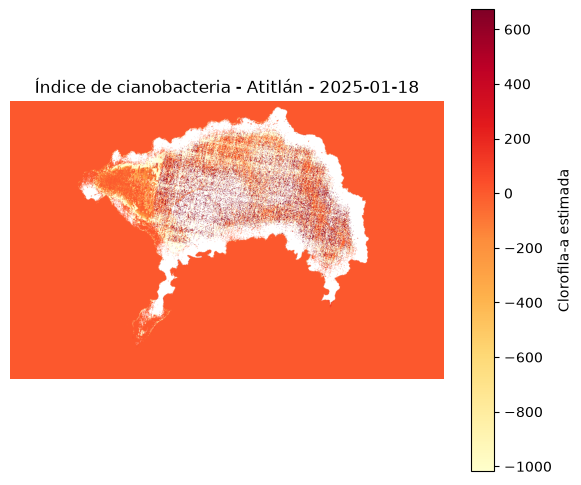

In [36]:
fecha_ejemplo_atitlan = fechas_atitlan[0]
plt.figure(figsize=(7, 6))
plt.imshow(resultados_atitlan[fecha_ejemplo_atitlan]["cianobacteria"], cmap="YlOrRd")
plt.title(f"Índice de cianobacteria - Atitlán - {fecha_ejemplo_atitlan}")
plt.colorbar(label="Clorofila-a estimada")
plt.axis("off")
plt.show()

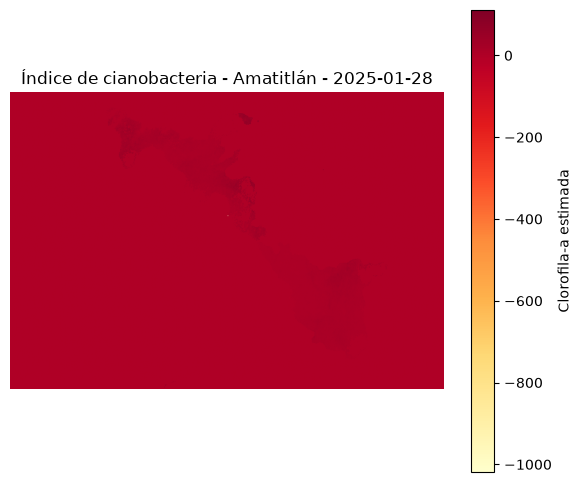

In [37]:
fecha_ejemplo_amatitlan = fechas_amatitlan[0]
plt.figure(figsize=(7, 6))
plt.imshow(resultados_amatitlan[fecha_ejemplo_amatitlan]["cianobacteria"], cmap="YlOrRd")
plt.title(f"Índice de cianobacteria - Amatitlán - {fecha_ejemplo_amatitlan}")
plt.colorbar(label="Clorofila-a estimada")
plt.axis("off")
plt.show()

## 4. Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

In [38]:
def promedio_cianobacteria(arr):
    valido = arr[arr > 0]
    if valido.size == 0:
        return np.nan
    return np.nanmean(valido)

In [39]:
promedio_atitlan = {fecha: promedio_cianobacteria(resultados_atitlan[fecha]["cianobacteria"]) for fecha in fechas_atitlan}

df_atitlan = pd.DataFrame(list(promedio_atitlan.items()), columns=["fecha", "cianobacteria_promedio"])
df_atitlan["fecha"] = pd.to_datetime(df_atitlan["fecha"])
df_atitlan = df_atitlan.sort_values("fecha").reset_index(drop=True)
df_atitlan

,fecha,cianobacteria_promedio
0,2025-01-18,381.082611
1,2025-04-13,3.229907
2,2025-05-13,3.622993
3,2025-07-17,4.240981
4,2025-11-21,7.468000
5,2025-12-29,4.948601
6,2026-02-12,6.826056
7,2026-03-24,3.672394
8,2026-04-13,3.552755
9,2026-04-28,3.138311


In [40]:
promedio_amatitlan = {fecha: promedio_cianobacteria(resultados_amatitlan[fecha]["cianobacteria"]) for fecha in fechas_amatitlan}

df_amatitlan = pd.DataFrame(list(promedio_amatitlan.items()), columns=["fecha", "cianobacteria_promedio"])
df_amatitlan["fecha"] = pd.to_datetime(df_amatitlan["fecha"])
df_amatitlan = df_amatitlan.sort_values("fecha").reset_index(drop=True)
df_amatitlan

,fecha,cianobacteria_promedio
0,2025-01-28,14.914059
1,2025-04-15,10.446157
2,2025-04-28,13.599401
3,2025-11-24,13.132152
4,2026-01-08,23.132414
5,2026-02-02,6.898146
6,2026-02-07,8.121027
7,2026-03-29,17.208698
8,2026-04-13,16.572437
9,2026-04-28,24.688444


### 4.2 Evolución temporal

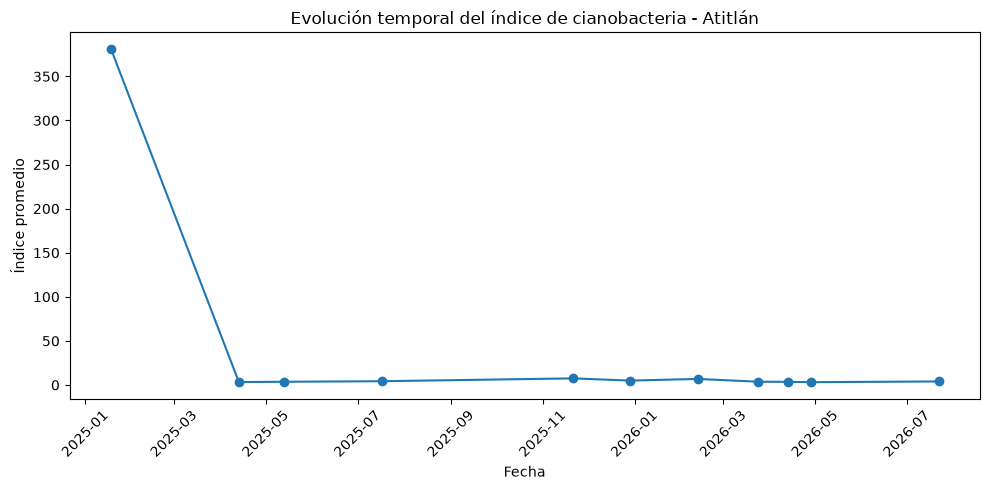

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(df_atitlan["fecha"], df_atitlan["cianobacteria_promedio"], marker="o")
plt.title("Evolución temporal del índice de cianobacteria - Atitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

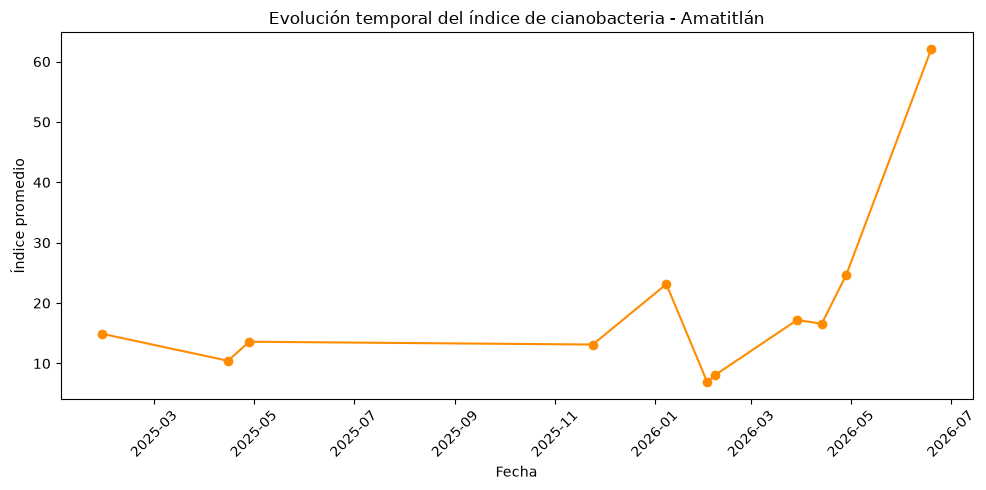

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(df_amatitlan["fecha"], df_amatitlan["cianobacteria_promedio"], marker="o", color="darkorange")
plt.title("Evolución temporal del índice de cianobacteria - Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Picos de floración y fechas críticas

In [43]:
pico_atitlan = df_atitlan.loc[df_atitlan["cianobacteria_promedio"].idxmax()]
pico_amatitlan = df_amatitlan.loc[df_amatitlan["cianobacteria_promedio"].idxmax()]

print("Pico Atitlán:", pico_atitlan["fecha"].date(), "-", round(pico_atitlan["cianobacteria_promedio"], 4))
print("Pico Amatitlán:", pico_amatitlan["fecha"].date(), "-", round(pico_amatitlan["cianobacteria_promedio"], 4))

Pico Atitlán: 2025-01-18 - 381.0826
Pico Amatitlán: 2026-06-19 - 62.0872


## 5. Ejercicio 1: Preparación de Datos para Machine Learning

### 1.1 Construcción del conjunto de datos etiquetado para Machine Learning

Se construye un dataset donde cada fila representa un píxel con sus características espectrales, ubicación geográfica, fecha y lago de origen.

In [44]:
def crear_dataset_ml(resultados_lago, fechas, bbox_dict, nombre_lago):
    """
    Convierte las imágenes raster en un dataset tabular para ML.
    Cada fila = un píxel con características y etiqueta (cianobacteria).
    """
    datos = []
    
    for fecha in fechas:
        if fecha not in resultados_lago:
            continue
            
        ndvi = resultados_lago[fecha]["ndvi"]
        ndwi = resultados_lago[fecha]["ndwi"]
        cianobacteria = resultados_lago[fecha]["cianobacteria"]
        
        # Obtener coordenadas del píxel
        altura, ancho = ndvi.shape
        
        # Calcular paso en grados
        lat_paso = (bbox_dict["north"] - bbox_dict["south"]) / altura
        lon_paso = (bbox_dict["east"] - bbox_dict["west"]) / ancho
        
        # Recorrer cada píxel
        for i in range(altura):
            for j in range(ancho):
                lat = bbox_dict["north"] - (i + 0.5) * lat_paso
                lon = bbox_dict["west"] + (j + 0.5) * lon_paso
                
                datos.append({
                    "fecha": fecha,
                    "lago": nombre_lago,
                    "latitud": lat,
                    "longitud": lon,
                    "ndvi": ndvi[i, j],
                    "ndwi": ndwi[i, j],
                    "cianobacteria": cianobacteria[i, j]
                })
    
    return pd.DataFrame(datos)

# Construir datasets para ambos lagos
print("Construyendo datasets...")
df_ml_atitlan = crear_dataset_ml(resultados_atitlan, fechas_atitlan, lago_atitlan, "Atitlán")
df_ml_amatitlan = crear_dataset_ml(resultados_amatitlan, fechas_amatitlan, lago_amatitlan, "Amatitlán")

# Combinar en un único dataset
df_ml = pd.concat([df_ml_atitlan, df_ml_amatitlan], ignore_index=True)

print(f"\nDataset total: {len(df_ml)} observaciones")
print(f"Atitlán: {len(df_ml_atitlan)} píxeles")
print(f"Amatitlán: {len(df_ml_amatitlan)} píxeles")
print(f"\nPrimeras filas:")
print(df_ml.head(10))

Construyendo datasets...

Dataset total: 16513585 observaciones
Atitlán: 13138125 píxeles
Amatitlán: 3375460 píxeles

Primeras filas:
        fecha     lago   latitud   longitud  ndvi  ndwi  cianobacteria
0  2025-01-18  Atitlán  14.75089 -91.326163   0.0   0.0            0.0
1  2025-01-18  Atitlán  14.75089 -91.325976   0.0   0.0            0.0
2  2025-01-18  Atitlán  14.75089 -91.325789   0.0   0.0            0.0
3  2025-01-18  Atitlán  14.75089 -91.325603   0.0   0.0            0.0
4  2025-01-18  Atitlán  14.75089 -91.325416   0.0   0.0            0.0
5  2025-01-18  Atitlán  14.75089 -91.325230   0.0   0.0            0.0
6  2025-01-18  Atitlán  14.75089 -91.325043   0.0   0.0            0.0
7  2025-01-18  Atitlán  14.75089 -91.324856   0.0   0.0            0.0
8  2025-01-18  Atitlán  14.75089 -91.324670   0.0   0.0            0.0
9  2025-01-18  Atitlán  14.75089 -91.324483   0.0   0.0            0.0


### 1.2 Características derivadas del dataset

Se derivan características adicionales a partir de NDVI, NDWI y la información geoespacial.

In [45]:
# Derivar características
df_ml["ndvi_ndwi_ratio"] = np.where(df_ml["ndwi"] != 0, df_ml["ndvi"] / (df_ml["ndwi"] + 1e-6), 0)
df_ml["ndvi_ndwi_sum"] = df_ml["ndvi"] + df_ml["ndwi"]
df_ml["ndvi_ndwi_diff"] = df_ml["ndvi"] - df_ml["ndwi"]

# Crear variable binaria para agua (basada en NDWI > 0.3)
df_ml["es_agua"] = (df_ml["ndwi"] > 0.3).astype(int)

# Crear variable binaria para presencia de cianobacteria (valor > 0)
df_ml["tiene_cianobacteria"] = (df_ml["cianobacteria"] > 0).astype(int)

# Convertir fecha a datetime
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"])

# Extraer características temporales
df_ml["mes"] = df_ml["fecha"].dt.month
df_ml["dia"] = df_ml["fecha"].dt.day
df_ml["año"] = df_ml["fecha"].dt.year

print("Características derivadas creadas:")
print(f"Total de características: {len(df_ml.columns)}")
print(f"\nColumnas del dataset:")
print(df_ml.columns.tolist())
print(f"\nForma del dataset: {df_ml.shape}")

Características derivadas creadas:
Total de características: 15

Columnas del dataset:
['fecha', 'lago', 'latitud', 'longitud', 'ndvi', 'ndwi', 'cianobacteria', 'ndvi_ndwi_ratio', 'ndvi_ndwi_sum', 'ndvi_ndwi_diff', 'es_agua', 'tiene_cianobacteria', 'mes', 'dia', 'año']

Forma del dataset: (16513585, 15)


### 1.3 Análisis exploratorio descriptivo

Análisis descriptivo de las variables espectrales principales: NDVI, NDWI e índice de cianobacteria.

In [46]:
# Estadísticas descriptivas de variables principales
print("=" * 80)
print("ANÁLISIS DESCRIPTIVO DEL DATASET")
print("=" * 80)

print("\n1. NDVI (Índice de Vegetación de Diferencia Normalizada)")
print("-" * 60)
print(df_ml["ndvi"].describe())

print("\n2. NDWI (Índice de Agua de Diferencia Normalizada)")
print("-" * 60)
print(df_ml["ndwi"].describe())

print("\n3. Cianobacteria (Variable Respuesta)")
print("-" * 60)
print(df_ml["cianobacteria"].describe())

# Estadísticas por lago
print("\n" + "=" * 80)
print("ESTADÍSTICAS POR LAGO")
print("=" * 80)

for lago in df_ml["lago"].unique():
    df_lago = df_ml[df_ml["lago"] == lago]
    print(f"\n{lago}:")
    print(f"  - Total de píxeles: {len(df_lago)}")
    print(f"  - NDVI: μ={df_lago['ndvi'].mean():.4f}, σ={df_lago['ndvi'].std():.4f}")
    print(f"  - NDWI: μ={df_lago['ndwi'].mean():.4f}, σ={df_lago['ndwi'].std():.4f}")
    print(f"  - Cianobacteria: μ={df_lago['cianobacteria'].mean():.4f}, σ={df_lago['cianobacteria'].std():.4f}")
    print(f"  - % píxeles con agua: {df_lago['es_agua'].mean()*100:.2f}%")
    print(f"  - % píxeles con cianobacteria: {df_lago['tiene_cianobacteria'].mean()*100:.2f}%")

ANÁLISIS DESCRIPTIVO DEL DATASET

1. NDVI (Índice de Vegetación de Diferencia Normalizada)
------------------------------------------------------------
count    1.651358e+07
mean     1.800340e-02
std      1.343527e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: ndvi, dtype: float64

2. NDWI (Índice de Agua de Diferencia Normalizada)
------------------------------------------------------------
count    1.651358e+07
mean    -1.772424e-02
std      1.336103e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: ndwi, dtype: float64

3. Cianobacteria (Variable Respuesta)
------------------------------------------------------------
count    1.634832e+07
mean    -2.323110e+00
std      6.977114e+01
min     -1.017929e+03
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.732110e+02
Name: cianobacteria, dtype: float64

ESTADÍSTICAS POR

### 1.4 Análisis de distribuciones por lago y por fecha

Análisis del número de observaciones disponibles por lago y por fecha.


Distribución por lago:
lago
Amatitlán     3375460
Atitlán      13138125
Name: count, dtype: int64


Distribución por fecha:
fecha
2025-01-18    1194375
2025-01-28     306860
2025-04-13    1194375
2025-04-15     306860
2025-04-28     306860
2025-05-13    1194375
2025-07-17    1194375
2025-11-21    1194375
2025-11-24     306860
2025-12-29    1194375
2026-01-08     306860
2026-02-02     306860
2026-02-07     306860
2026-02-12    1194375
2026-03-24    1194375
2026-03-29     306860
2026-04-13    1501235
2026-04-28    1501235
2026-06-19     306860
2026-07-22    1194375
Name: count, dtype: int64


Distribución lago × fecha:
fecha      2025-01-18  2025-01-28  2025-04-13  2025-04-15  2025-04-28  \
lago                                                                    
Amatitlán           0      306860           0      306860      306860   
Atitlán       1194375           0     1194375           0           0   

fecha      2025-05-13  2025-07-17  2025-11-21  2025-11-24  2025-12-29  \
lago    

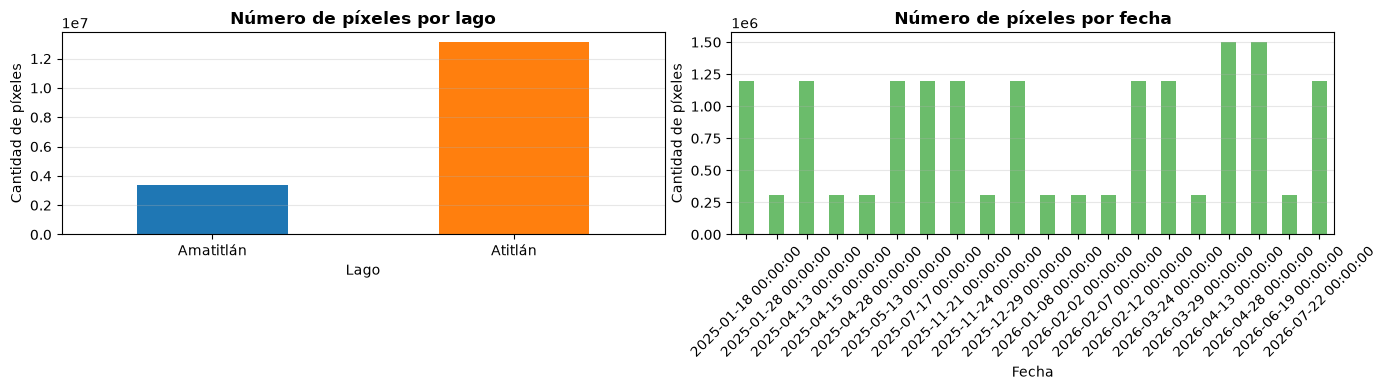

In [47]:
# Distribución de observaciones por lago
print("\nDistribución por lago:")
dist_lago = df_ml["lago"].value_counts().sort_index()
print(dist_lago)

# Distribución de observaciones por fecha
print("\n\nDistribución por fecha:")
dist_fecha = df_ml["fecha"].value_counts().sort_index()
print(dist_fecha)

# Distribución cruzada: lago × fecha
print("\n\nDistribución lago × fecha:")
dist_cruzada = pd.crosstab(df_ml["lago"], df_ml["fecha"].dt.date)
print(dist_cruzada)

# Visualización: observaciones por lago
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: Observaciones por lago
dist_lago.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Número de píxeles por lago", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Lago")
axes[0].set_ylabel("Cantidad de píxeles")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# Gráfico 2: Observaciones por fecha
dist_fecha.plot(kind="bar", ax=axes[1], color="#2ca02c", alpha=0.7)
axes[1].set_title("Número de píxeles por fecha", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Cantidad de píxeles")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5 Análisis exploratorio de variables con histogramas y estadísticas

Histogramas y distribuciones de NDVI, NDWI y cianobacteria para identificar patrones y valores atípicos.

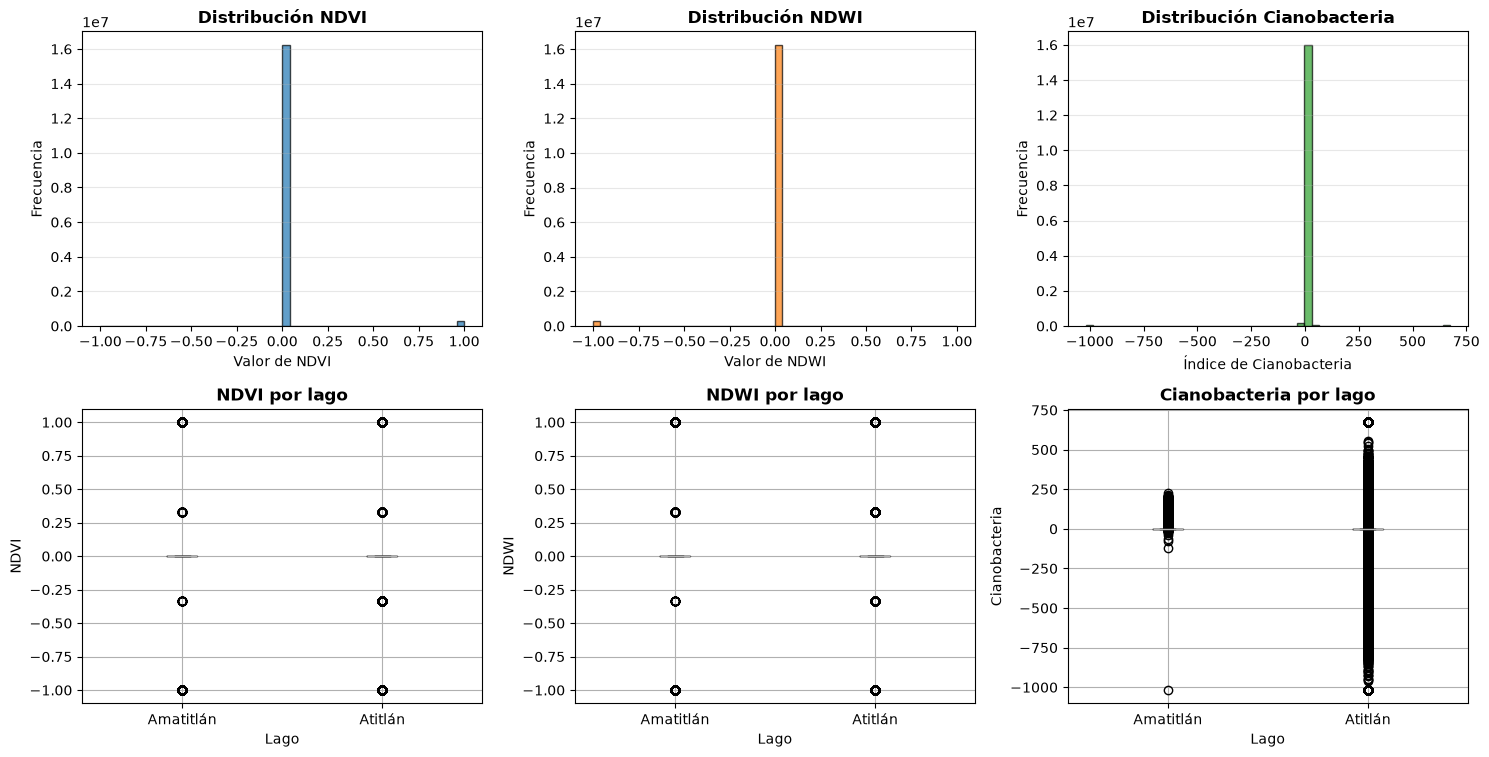


Matriz de correlación (variables principales):
                  ndvi      ndwi  cianobacteria
ndvi           1.00000 -0.987840       0.004480
ndwi          -0.98784  1.000000      -0.004431
cianobacteria  0.00448 -0.004431       1.000000


In [48]:
# Histogramas de las variables principales
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# NDVI
axes[0, 0].hist(df_ml["ndvi"], bins=50, color="#1f77b4", alpha=0.7, edgecolor="black")
axes[0, 0].set_title("Distribución NDVI", fontweight="bold")
axes[0, 0].set_xlabel("Valor de NDVI")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(axis="y", alpha=0.3)

# NDWI
axes[0, 1].hist(df_ml["ndwi"], bins=50, color="#ff7f0e", alpha=0.7, edgecolor="black")
axes[0, 1].set_title("Distribución NDWI", fontweight="bold")
axes[0, 1].set_xlabel("Valor de NDWI")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].grid(axis="y", alpha=0.3)

# Cianobacteria
axes[0, 2].hist(df_ml["cianobacteria"], bins=50, color="#2ca02c", alpha=0.7, edgecolor="black")
axes[0, 2].set_title("Distribución Cianobacteria", fontweight="bold")
axes[0, 2].set_xlabel("Índice de Cianobacteria")
axes[0, 2].set_ylabel("Frecuencia")
axes[0, 2].grid(axis="y", alpha=0.3)

# Box plots por lago
df_ml.boxplot(column="ndvi", by="lago", ax=axes[1, 0])
axes[1, 0].set_title("NDVI por lago", fontweight="bold")
axes[1, 0].set_xlabel("Lago")
axes[1, 0].set_ylabel("NDVI")

df_ml.boxplot(column="ndwi", by="lago", ax=axes[1, 1])
axes[1, 1].set_title("NDWI por lago", fontweight="bold")
axes[1, 1].set_xlabel("Lago")
axes[1, 1].set_ylabel("NDWI")

df_ml.boxplot(column="cianobacteria", by="lago", ax=axes[1, 2])
axes[1, 2].set_title("Cianobacteria por lago", fontweight="bold")
axes[1, 2].set_xlabel("Lago")
axes[1, 2].set_ylabel("Cianobacteria")

plt.tight_layout()
plt.suptitle("")  # Remover título automático
plt.show()

# Correlación entre variables
print("\nMatriz de correlación (variables principales):")
corr_vars = df_ml[["ndvi", "ndwi", "cianobacteria"]].corr()
print(corr_vars)

### 1.6 Análisis de la distribución de la variable respuesta (cianobacteria)

Análisis detallado de la distribución del índice de cianobacteria globalmente, por lago y por fecha.

ANÁLISIS DE LA VARIABLE RESPUESTA: CIANOBACTERIA

Globalmente:
  Valores > 0: 2081131 (12.60%)
  Valores = 0: 13880688 (84.06%)
  Valores = -1: 722 (0.00%)

Por lago:

  Amatitlán:
    - Píxeles con cianobacteria: 259891 (7.70%)
    - Píxeles sin detectar agua: 3114859 (92.28%)
    - Píxeles con floración superficial: 671 (0.02%)

  Atitlán:
    - Píxeles con cianobacteria: 1821240 (13.86%)
    - Píxeles sin detectar agua: 10765829 (81.94%)
    - Píxeles con floración superficial: 51 (0.00%)


Por fecha (promedio de cianobacteria para píxeles con agua):
             count        mean         std       min         max
fecha                                                           
2025-01-18   55593  381.082611  319.580811  0.014322  673.210999
2025-01-28   27816   14.914059    8.721342  1.575714  111.646606
2025-04-13  222755    3.229907    0.901058  0.000348   22.445086
2025-04-15   11756   10.446156    8.935078  2.161159   73.916359
2025-04-28   23223   13.599401   15.985321  0.4531

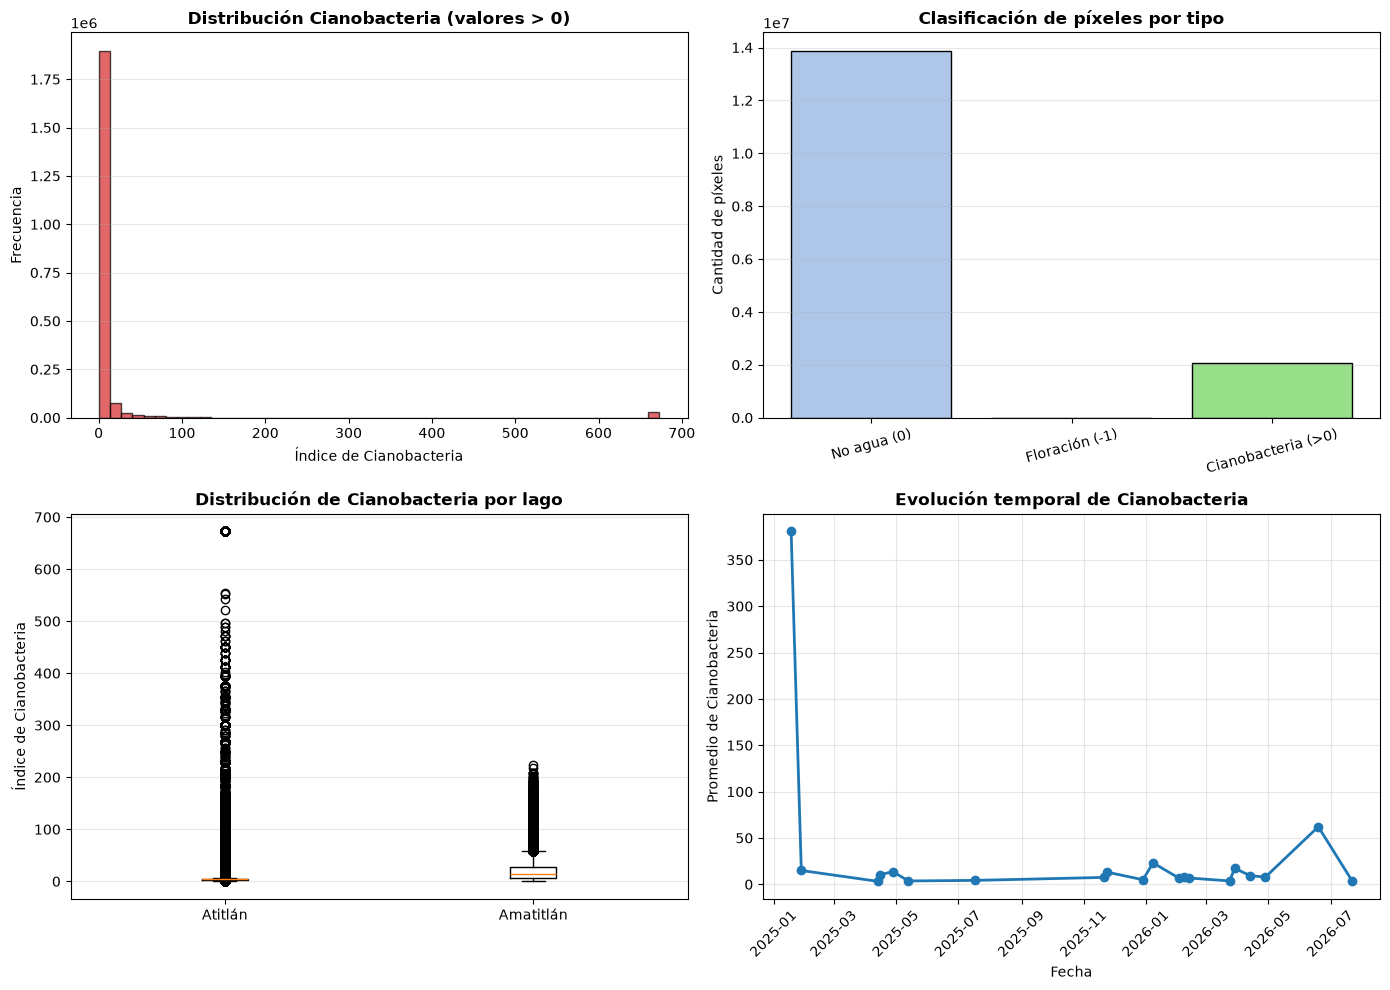

In [51]:
# Análisis de la variable respuesta: cianobacteria
print("=" * 80)
print("ANÁLISIS DE LA VARIABLE RESPUESTA: CIANOBACTERIA")
print("=" * 80)

# Estadísticas globales
print("\nGlobalmente:")
print(f"  Valores > 0: {(df_ml['cianobacteria'] > 0).sum()} ({(df_ml['cianobacteria'] > 0).mean()*100:.2f}%)")
print(f"  Valores = 0: {(df_ml['cianobacteria'] == 0).sum()} ({(df_ml['cianobacteria'] == 0).mean()*100:.2f}%)")
print(f"  Valores = -1: {(df_ml['cianobacteria'] == -1).sum()} ({(df_ml['cianobacteria'] == -1).mean()*100:.2f}%)")

# Por lago
print("\nPor lago:")
for lago in sorted(df_ml["lago"].unique()):
    df_lago = df_ml[df_ml["lago"] == lago]
    print(f"\n  {lago}:")
    print(f"    - Píxeles con cianobacteria: {(df_lago['cianobacteria'] > 0).sum()} ({(df_lago['cianobacteria'] > 0).mean()*100:.2f}%)")
    print(f"    - Píxeles sin detectar agua: {(df_lago['cianobacteria'] == 0).sum()} ({(df_lago['cianobacteria'] == 0).mean()*100:.2f}%)")
    print(f"    - Píxeles con floración superficial: {(df_lago['cianobacteria'] == -1).sum()} ({(df_lago['cianobacteria'] == -1).mean()*100:.2f}%)")

# Por fecha (solo para observaciones positivas)
print("\n\nPor fecha (promedio de cianobacteria para píxeles con agua):")
df_con_agua = df_ml[df_ml["cianobacteria"] > 0]
promedio_por_fecha = df_con_agua.groupby("fecha")["cianobacteria"].agg(["count", "mean", "std", "min", "max"])
print(promedio_por_fecha)

# Visualizaciones de la variable respuesta
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución global (excluyendo 0 y -1)
df_positivo = df_ml[df_ml["cianobacteria"] > 0]
axes[0, 0].hist(df_positivo["cianobacteria"], bins=50, color="#d62728", alpha=0.7, edgecolor="black")
axes[0, 0].set_title("Distribución Cianobacteria (valores > 0)", fontweight="bold")
axes[0, 0].set_xlabel("Índice de Cianobacteria")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(axis="y", alpha=0.3)

# Proporción de píxeles por categoría
categorias = ["No agua (0)", "Floración (-1)", "Cianobacteria (>0)"]
valores = [
    (df_ml["cianobacteria"] == 0).sum(),
    (df_ml["cianobacteria"] == -1).sum(),
    (df_ml["cianobacteria"] > 0).sum()
]
colores = ["#aec7e8", "#ffbb78", "#98df8a"]
axes[0, 1].bar(categorias, valores, color=colores, edgecolor="black")
axes[0, 1].set_title("Clasificación de píxeles por tipo", fontweight="bold")
axes[0, 1].set_ylabel("Cantidad de píxeles")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].grid(axis="y", alpha=0.3)

# Cianobacteria por lago (box plot de valores positivos)
df_lago_atitlan = df_positivo[df_positivo["lago"] == "Atitlán"]["cianobacteria"]
df_lago_amatitlan = df_positivo[df_positivo["lago"] == "Amatitlán"]["cianobacteria"]
bp = axes[1, 0].boxplot([df_lago_atitlan, df_lago_amatitlan])
axes[1, 0].set_xticklabels(["Atitlán", "Amatitlán"])
axes[1, 0].set_title("Distribución de Cianobacteria por lago", fontweight="bold")
axes[1, 0].set_ylabel("Índice de Cianobacteria")
axes[1, 0].grid(axis="y", alpha=0.3)

# Evolución temporal de cianobacteria
promedio_temporal = df_con_agua.groupby("fecha")["cianobacteria"].mean().sort_index()
axes[1, 1].plot(promedio_temporal.index, promedio_temporal.values, marker="o", linewidth=2, markersize=6, color="#1f77b4")
axes[1, 1].set_title("Evolución temporal de Cianobacteria", fontweight="bold")
axes[1, 1].set_xlabel("Fecha")
axes[1, 1].set_ylabel("Promedio de Cianobacteria")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
